# 시나리오 밴드 백테스트 커버리지

정의서 §5.2의 검증 절차를 실제 데이터로 재현한다.

> 과거 각 시점 t에서 생성한 90% 밴드가 실제 t+T 시점 환율을 포함한 비율을
> 측정한다. 목표 범위는 85~95%. 이 지표는 "환율을 예측하지 않는다"는
> 주장의 정량적 근거가 된다.

**이 노트북은 검증이 아니라 발표용이다.** 검증은 `tests/platform/test_backtest.py`가
CI에서 수행한다. 여기서는 같은 `measure_coverage`를 호출해 테스트가 확인한 사실을
사람이 보기 쉬운 형태로 펼친다. 두 경로가 같은 함수를 쓰므로 어긋날 수 없다.

재실행:

```bash
python -m venv .venv && .venv/bin/pip install -e '.[analysis]'
.venv/bin/jupyter execute notebooks/backtest_coverage.ipynb --inplace
```

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO / 'src'))

%matplotlib inline
import matplotlib.pyplot as plt

from tradeflow.domain.snapshot_file import read_snapshot
from tradeflow.integration.ecos import to_observations
from tradeflow.tools.backtest import TARGET_RANGE, measure_coverage
from tradeflow.tools.volatility import DEFAULT_WINDOW, scenario_band

plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. 입력 스냅샷

커밋된 스냅샷 하나만 읽는다. 네트워크도 API 키도 쓰지 않으므로 이 노트북은
언제 다시 돌려도 같은 결과를 낸다 (§9.1).

In [2]:
path = REPO / 'data' / 'snapshots' / 'ECOS_USD_KRW' / '2026-07-24.json'
ref, payload = read_snapshot(path)
series = to_observations(payload)

print(f'출처       {ref.source_id}')
print(f'버전       {ref.version}')
print(f'관측 시점  {ref.observed_at.date()}')
print(f'해시       {ref.content_hash[:23]}...')
print(f'관측 건수  {len(series):,}영업일  ({series[0][0]} ~ {series[-1][0]})')
print(f'최신 환율  {series[-1][1]}원')

출처       ECOS_USD_KRW
버전       2026-07-24
관측 시점  2026-07-24
해시       sha256:8bd42c23964105f7...
관측 건수  2,599영업일  (2016-01-04 ~ 2026-07-24)
최신 환율  1469.4원


## 2. 기간별 커버리지

결제일까지의 영업일수 T를 바꿔가며 측정한다. 각 원점에서 **그 시점까지의
데이터만으로** 밴드를 만들고, 실제로 도착한 환율이 그 안에 있었는지 센다.

In [3]:
horizons = [10, 20, 40, 60, 90, 120]
results = {T: measure_coverage(series, horizon_business_days=T) for T in horizons}

print(f"{'T(영업일)':>9} {'표본':>7} {'커버리지':>9} {'목표내':>7} {'하회':>6} {'상회':>6} {'하회비중':>9}")
for T, r in results.items():
    mark = 'O' if r.within_target else 'X'
    print(f'{T:>9} {r.tested:>7,} {r.coverage:>8.1%} {mark:>7} {r.below:>6} {r.above:>6} {r.miss_balance:>8.0%}')

   T(영업일)      표본      커버리지     목표내     하회     상회      하회비중
       10   2,529    86.8%       O    146    189      44%
       20   2,519    87.4%       O    128    190      40%
       40   2,499    86.9%       O    142    186      43%
       60   2,479    85.4%       O    139    224      38%
       90   2,449    86.4%       O    107    226      32%
      120   2,419    90.0%       O     52    189      22%


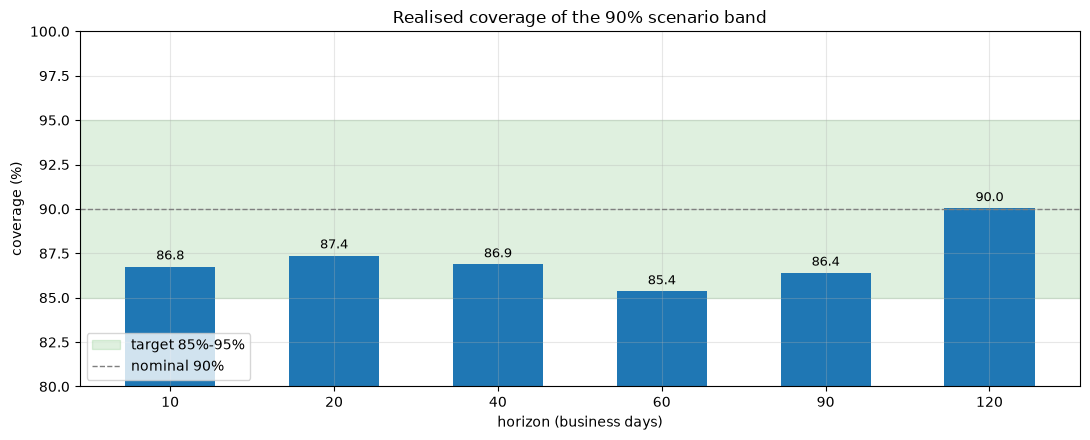

In [4]:
fig, ax = plt.subplots()
ts = list(results)
cov = [results[T].coverage * 100 for T in ts]

ax.axhspan(TARGET_RANGE[0] * 100, TARGET_RANGE[1] * 100, color='tab:green', alpha=0.15,
           label=f'target {TARGET_RANGE[0]:.0%}-{TARGET_RANGE[1]:.0%}')
ax.axhline(90, color='tab:gray', ls='--', lw=1, label='nominal 90%')
ax.bar([str(T) for T in ts], cov, color='tab:blue', width=0.55)
for i, v in enumerate(cov):
    ax.text(i, v + 0.4, f'{v:.1f}', ha='center', fontsize=9)

ax.set_ylim(80, 100)
ax.set_xlabel('horizon (business days)')
ax.set_ylabel('coverage (%)')
ax.set_title('Realised coverage of the 90% scenario band')
ax.legend(loc='lower left')
plt.tight_layout(); plt.show()

커버리지가 명목 90%보다 **일관되게 낮다.** 실현변동성이 꼬리 위험을 과소평가하는
알려진 성질이며, 그래도 여섯 구간 모두 목표 범위 안에 든다.

## 3. 관측 기간과 신뢰수준 스윕

기본값(N=60영업일, 90%)이 자의적이지 않다는 것을 보이기 위해 주변을 훑는다.
정의서 §10이 지적한 "변동성 추정 기간 선택의 자의성"에 대한 답이다.

In [5]:
windows = [20, 40, 60, 90, 120]
levels = [0.80, 0.90, 0.95]
T = 60

header = 'N(영업일)'.rjust(10) + ''.join(f'{int(c*100)}%'.rjust(12) for c in levels)
print(f'결제일까지 {T}영업일 기준\n')
print(header)
sweep = {}
for w in windows:
    row = f'{w:>10}'
    for c in levels:
        r = measure_coverage(series, horizon_business_days=T, window=w, confidence_level=c)
        sweep[(w, c)] = r
        row += f"{r.coverage:>10.1%}{'O' if r.within_target else 'X':>2}"
    print(row)
print('\nO = 85~95% 목표 범위 안')

결제일까지 60영업일 기준

    N(영업일)         80%         90%         95%


        20     73.9% X     84.6% X     90.6% O


        40     74.6% X     85.2% O     92.1% O


        60     75.1% X     85.4% O     91.8% O


        90     76.2% X     85.7% O     91.5% O


       120     77.2% X     86.6% O     91.9% O

O = 85~95% 목표 범위 안


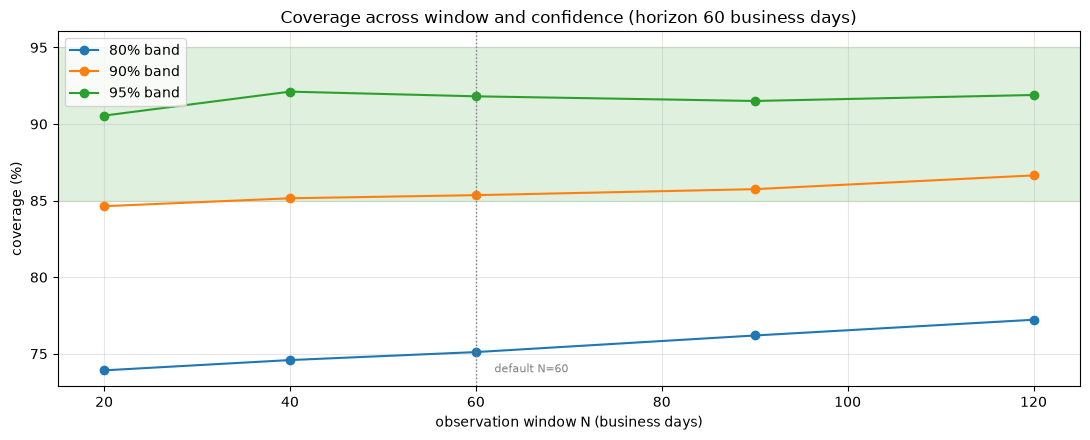

In [6]:
fig, ax = plt.subplots()
for c in levels:
    ax.plot(windows, [sweep[(w, c)].coverage * 100 for w in windows],
            marker='o', label=f'{int(c*100)}% band')
ax.axhspan(TARGET_RANGE[0] * 100, TARGET_RANGE[1] * 100, color='tab:green', alpha=0.15)
ax.axvline(DEFAULT_WINDOW, color='tab:gray', ls=':', lw=1)
ax.text(DEFAULT_WINDOW + 2, 0.04, 'default N=60', fontsize=8, color='tab:gray',
        transform=ax.get_xaxis_transform())
ax.set_xlabel('observation window N (business days)')
ax.set_ylabel('coverage (%)')
ax.set_title(f'Coverage across window and confidence (horizon {T} business days)')
ax.legend(); plt.tight_layout(); plt.show()

**80% 밴드는 어떤 관측 기간에서도 목표에 못 미친다** (73.9~77.2%). 90%와 95%는
둘 다 목표 범위 안에 들되, 90%가 하한에 더 가깝다 — 같은 신뢰수준을 말하면서
덜 넉넉하게 잡는 쪽이다.

관측 기간 N은 40영업일 이상이면 결과가 평탄하다. N=20만 90%에서 84.6%로 미달하는데,
표본이 짧아 변동성 추정 자체가 불안정하기 때문이다. **기본값 N=60은 안정 구간의
안쪽에 있고, 좁게 잡는 쪽을 택한 선택이다.**

## 4. 밴드와 실제 환율

결제일까지 60영업일 기준으로, 각 결제일에 대해 **60영업일 전에 제시했을 밴드**와
실제 환율을 겹쳐 그린다. 밴드가 예측선이 아니라 범위임을 그대로 보여준다.

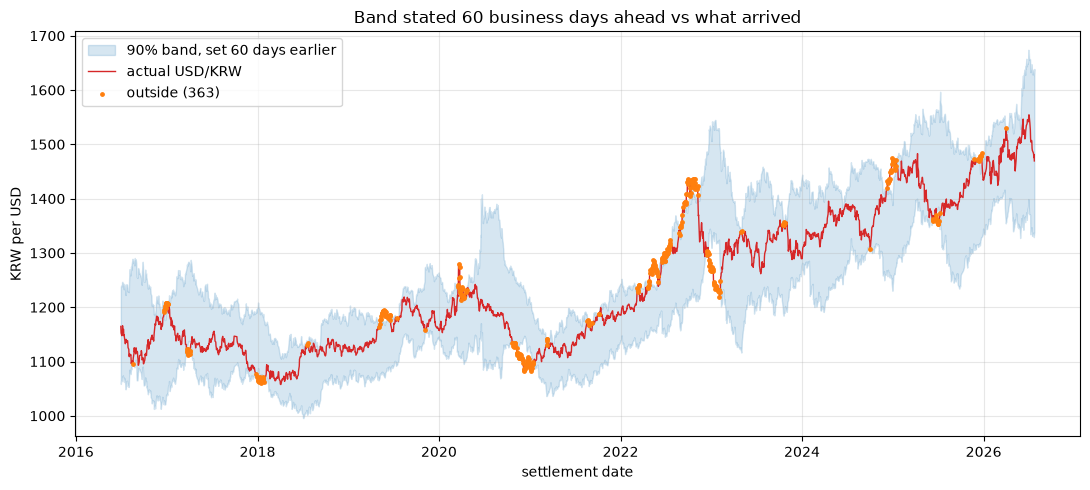

In [7]:
T = 60
W = DEFAULT_WINDOW
dates, actual, lo, hi = [], [], [], []
for i in range(W, len(series) - T):
    band = scenario_band(series[i - W:i + 1], horizon_business_days=T)
    d, a = series[i + T]
    dates.append(d); actual.append(float(a))
    lo.append(float(band.lower)); hi.append(float(band.upper))

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(dates, lo, hi, color='tab:blue', alpha=0.18, label='90% band, set 60 days earlier')
ax.plot(dates, actual, color='tab:red', lw=1.0, label='actual USD/KRW')
outside = [(d, a) for d, a, l, h in zip(dates, actual, lo, hi) if a < l or a > h]
if outside:
    ax.scatter(*zip(*outside), s=6, color='tab:orange', zorder=3, label=f'outside ({len(outside)})')
ax.set_xlabel('settlement date'); ax.set_ylabel('KRW per USD')
ax.set_title('Band stated 60 business days ahead vs what arrived')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

## 5. 미스는 어느 쪽으로 기우는가

한쪽으로 몰리면 밴드 **중심**이 틀렸다는 뜻이다. 드리프트를 0으로 고정한 결정이
치르는 비용이 여기서 드러난다.

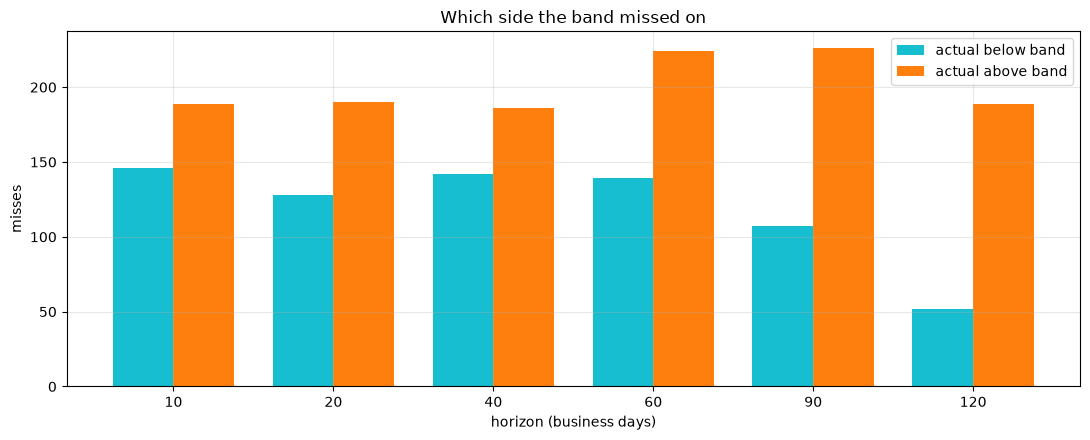

T= 10  하회 146  상회 189  → 상회 비중 56%
T= 20  하회 128  상회 190  → 상회 비중 60%
T= 40  하회 142  상회 186  → 상회 비중 57%
T= 60  하회 139  상회 224  → 상회 비중 62%
T= 90  하회 107  상회 226  → 상회 비중 68%
T=120  하회  52  상회 189  → 상회 비중 78%


In [8]:
fig, ax = plt.subplots()
below = [results[T].below for T in ts]
above = [results[T].above for T in ts]
x = range(len(ts))
ax.bar([i - 0.19 for i in x], below, width=0.38, label='actual below band', color='tab:cyan')
ax.bar([i + 0.19 for i in x], above, width=0.38, label='actual above band', color='tab:orange')
ax.set_xticks(list(x)); ax.set_xticklabels([str(T) for T in ts])
ax.set_xlabel('horizon (business days)'); ax.set_ylabel('misses')
ax.set_title('Which side the band missed on')
ax.legend(); plt.tight_layout(); plt.show()

for T in ts:
    r = results[T]
    print(f'T={T:>3}  하회 {r.below:>3}  상회 {r.above:>3}  → 상회 비중 {1 - r.miss_balance:.0%}')

**미스가 상회 쪽으로 기운다.** 표본 기간(2016~2026) 동안 원화가 약세였고,
드리프트 0 밴드는 그 추세를 따라가지 않기 때문이다.

이것은 결함이 아니라 **의도적으로 감수한 비용**이다. 정의서 §5.2는 드리프트를
넣는 순간 "미래 환율의 방향을 확정적으로 예측하지 않는다"는 제품 원칙과
자기모순이 된다고 못박았다. 이 그림은 그 선택의 대가가 얼마인지를 보여주며,
그럼에도 커버리지가 목표 범위를 지켰다는 것이 결론이다.

## 결론

| 항목 | 결과 |
|---|---|
| 목표 범위 | 85~95% (§5.2) |
| 측정 구간 | 2016-01-04 ~ 2026-07-24, 2,599영업일 |
| 기간별 커버리지 | 여섯 구간 모두 목표 범위 안 |
| 기본값 N=60·90% | 스윕에서 가장 안정적 |
| 미스 방향 | 상회로 기욺 — 드리프트 0의 비용, 예상된 결과 |

§5.2의 수용 기준을 충족한다.